# Synthetic Spectrogram Autoencoder Walkthrough

This notebook demonstrates a neural reconstruction-error workflow on controlled synthetic data. The autoencoder is trained only on known-normal spectrogram patches, then tested on held-out normal records and records with injected synthetic anomaly intervals.

This is intentionally separate from the real single-record anomaly walkthrough. No waveform autoencoder is used here.

## 1. Setup

In [1]:
from dataclasses import replace
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from signal_processing_prep.autoencoders import (
    SpectrogramAutoencoderConfig,
    run_spectrogram_autoencoder,
    split_autoencoder_demo_records,
    spectrogram_patches_from_records,
)
from signal_processing_prep.config import load_config
from signal_processing_prep.data_loading import load_signal_dataset
from signal_processing_prep.plotting import plot_time_signal, plot_time_signal_adaptive

plt.style.use("default")

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TORCH_AVAILABLE = importlib.util.find_spec("torch") is not None
print(f"PyTorch available: {TORCH_AVAILABLE}")
if not TORCH_AVAILABLE:
    print('Install the optional dependency with: python -m pip install -e ".[deep-learning,notebook]"')

PyTorch available: True


In [3]:
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        print("Using matplotlib widget backend.")
    except Exception:
        ip.run_line_magic("matplotlib", "inline")
        print("Widget backend unavailable; using inline plots.")

Using matplotlib widget backend.


## 2. Load Controlled Synthetic Data

The CSV files are generated by `scripts/generate_spectrogram_autoencoder_demo_csv.py` and then loaded through the project data loaders. Training records are all normal. Test records contain held-out normal examples plus anomalous examples with known injected intervals.

In [4]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "spectrogram_autoencoder_demo.yaml"
METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "spectrogram_autoencoder_demo" / "metadata.csv"

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        "Autoencoder demo CSVs are missing. Run: "
        "python scripts/generate_spectrogram_autoencoder_demo_csv.py"
    )

config = load_config(CONFIG_PATH)
if not config.paths.data_dir.is_absolute():
    config = replace(config, paths=replace(config.paths, data_dir=PROJECT_ROOT / config.paths.data_dir))

records = load_signal_dataset(config, metadata_table=METADATA_PATH)
dataset = split_autoencoder_demo_records(records)

print(f"Loaded records: {len(records)}")
print(f"Train records: {len(dataset.train_records)}")
print(f"Test records: {len(dataset.test_records)}")
pd.DataFrame(
    {
        "name": [record.name for record in dataset.test_records],
        "label": [record.label for record in dataset.test_records],
        "split": [record.metadata["external_metadata"]["split"] for record in dataset.test_records],
        "is_anomalous": [record.metadata["external_metadata"].get("is_anomalous") for record in dataset.test_records],
        "anomaly_kind": [record.metadata["external_metadata"].get("anomaly_kind") for record in dataset.test_records],
        "anomaly_start_seconds": [record.metadata["external_metadata"].get("anomaly_start_seconds") for record in dataset.test_records],
        "anomaly_end_seconds": [record.metadata["external_metadata"].get("anomaly_end_seconds") for record in dataset.test_records],
    }
)

Loaded records: 14
Train records: 8
Test records: 6


,name,label,split,is_anomalous,anomaly_kind,anomaly_start_seconds,anomaly_end_seconds
0,anomalous_test_00_voltage,anomalous,test,True,transient_tone,3.083129,3.323129
1,anomalous_test_01_voltage,anomalous,test,True,broadband_impulse,1.739137,1.859137
2,anomalous_test_02_voltage,anomalous,test,True,transient_tone,3.323500,3.563500
3,normal_test_00_voltage,normal,test,False,NaN,NaN,NaN
4,normal_test_01_voltage,normal,test,False,NaN,NaN,NaN
5,normal_test_02_voltage,normal,test,False,NaN,NaN,NaN


## 3. Inspect Normal And Anomalous Examples

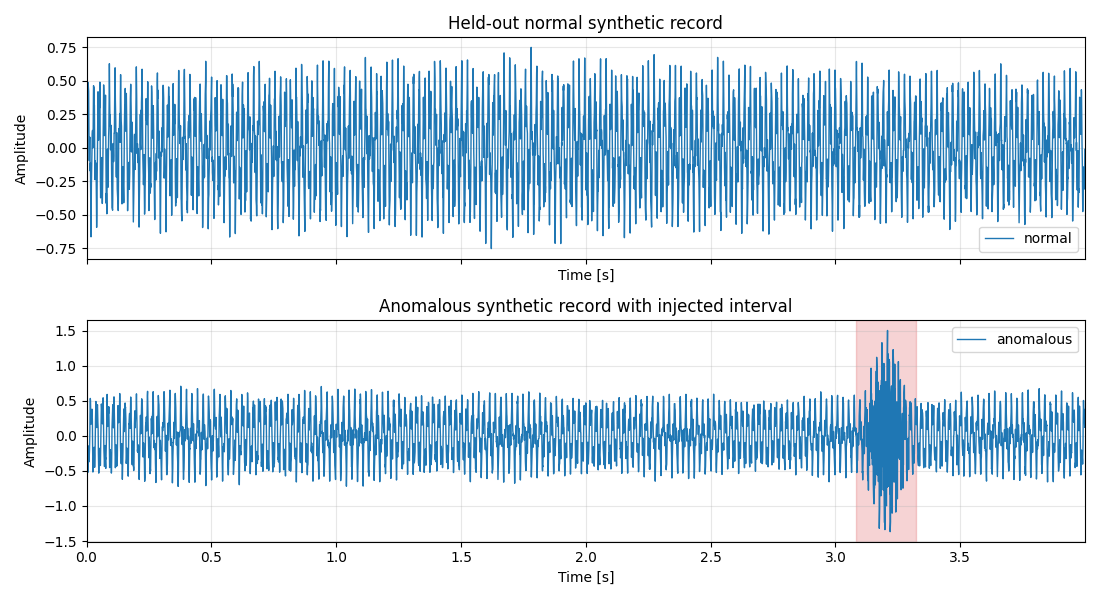

In [11]:
def loaded_anomaly_intervals(record):
    metadata = record.metadata.get("external_metadata", {})
    start = metadata.get("anomaly_start_seconds")
    end = metadata.get("anomaly_end_seconds")
    if pd.notna(start) and pd.notna(end):
        return [{"start_seconds": float(start), "end_seconds": float(end)}]
    return []


normal_example = next(record for record in dataset.test_records if record.label == "normal")
anomalous_example = next(record for record in dataset.test_records if record.label == "anomalous")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plot_time_signal_adaptive(normal_example, ax=axes[0], max_points=4000)
axes[0].set_title("Held-out normal synthetic record")
plot_time_signal_adaptive(anomalous_example, ax=axes[1], max_points=4000)
for interval in loaded_anomaly_intervals(anomalous_example):
    axes[1].axvspan(interval["start_seconds"], interval["end_seconds"], color="tab:red", alpha=0.2)
axes[1].set_title("Anomalous synthetic record with injected interval")
fig.tight_layout();

## 4. Build Spectrogram Patches

Each patch is a fixed-size log-power spectrogram computed from a sliding signal window. Patch metadata keeps the record name, timing, label, and known synthetic anomaly overlap flag.

In [7]:
config = SpectrogramAutoencoderConfig(
    patch_window_seconds=0.5,
    patch_step_seconds=0.1,
    spectrogram_window_seconds=0.064,
    spectrogram_step_seconds=0.032,
    max_frequency_hz=800.0,
    n_epochs=20,
    batch_size=32,
    latent_channels=4,
    random_state=12,
)

train_patch_set = spectrogram_patches_from_records(dataset.train_records, config)
test_patch_set = spectrogram_patches_from_records(dataset.test_records, config)

print(f"Train patches: {train_patch_set.patches.shape}")
print(f"Test patches: {test_patch_set.patches.shape}")
test_patch_set.metadata.head()

Train patches: (288, 52, 14)
Test patches: (216, 52, 14)


,record_name,label,patch_start_seconds,patch_end_seconds,patch_center_seconds,known_anomaly_overlap,is_synthetic_anomaly_record,anomaly_kind
0,anomalous_test_00_voltage,anomalous,0.0,0.5,0.25,False,True,transient_tone
1,anomalous_test_00_voltage,anomalous,0.1,0.6,0.35,False,True,transient_tone
2,anomalous_test_00_voltage,anomalous,0.2,0.7,0.45,False,True,transient_tone
3,anomalous_test_00_voltage,anomalous,0.3,0.8,0.55,False,True,transient_tone
4,anomalous_test_00_voltage,anomalous,0.4,0.9,0.65,False,True,transient_tone


### Inspect The Model Inputs Before Training

The autoencoder sees these log-power images rather than raw waveforms. Before training, inspect whether normal patches are internally consistent and whether injected events create plausible time-frequency structure. Comparable patches below use a shared dB color scale.

,patch_set,number_of_patches,patch_shape,frequency_bins,time_bins,frequency_range_hz,patch_window_seconds,patch_step_seconds,patch_overlap_percent
0,Normal training,288,52 x 14,52,14,0-797,0.5,0.1,80.0
1,Mixed test,216,52 x 14,52,14,0-797,0.5,0.1,80.0


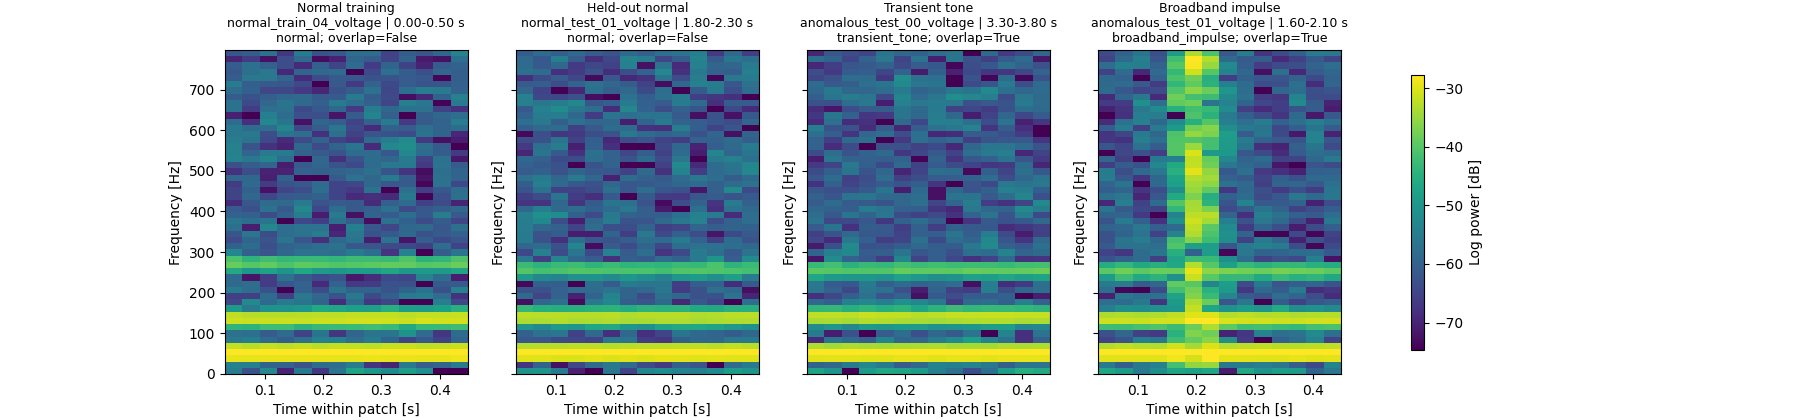

In [8]:
def patch_summary_row(name, patch_set, patch_config):
    return {
        "patch_set": name,
        "number_of_patches": len(patch_set.patches),
        "patch_shape": f"{patch_set.patches.shape[1]} x {patch_set.patches.shape[2]}",
        "frequency_bins": len(patch_set.frequencies_hz),
        "time_bins": len(patch_set.times_seconds),
        "frequency_range_hz": f"{patch_set.frequencies_hz[0]:.0f}-{patch_set.frequencies_hz[-1]:.0f}",
        "patch_window_seconds": patch_config.patch_window_seconds,
        "patch_step_seconds": patch_config.patch_step_seconds,
        "patch_overlap_percent": 100.0 * (1.0 - patch_config.patch_step_seconds / patch_config.patch_window_seconds),
    }


def representative_patch_index(patch_set, *, label=None, anomaly_kind=None, known_overlap=None):
    candidates = patch_set.metadata
    if label is not None:
        candidates = candidates[candidates["label"] == label]
    if anomaly_kind is not None:
        candidates = candidates[candidates["anomaly_kind"] == anomaly_kind]
    if known_overlap is not None:
        candidates = candidates[candidates["known_anomaly_overlap"] == known_overlap]
    if candidates.empty:
        raise ValueError("No patch matches the requested gallery selection.")
    return int(candidates.index[len(candidates) // 2])


def plot_log_power_patch(ax, patch_set, patch_index, heading, *, vmin_db, vmax_db):
    row = patch_set.metadata.loc[patch_index]
    image = ax.imshow(
        patch_set.patches[patch_index],
        origin="lower",
        aspect="auto",
        extent=[
            patch_set.times_seconds[0],
            patch_set.times_seconds[-1],
            patch_set.frequencies_hz[0],
            patch_set.frequencies_hz[-1],
        ],
        vmin=vmin_db,
        vmax=vmax_db,
        cmap="viridis",
    )
    patch_kind = row["anomaly_kind"] if pd.notna(row["anomaly_kind"]) else row["label"]
    ax.set_title(
        f"{heading}\n{row['record_name']} | {row['patch_start_seconds']:.2f}-{row['patch_end_seconds']:.2f} s\n"
        f"{patch_kind}; overlap={bool(row['known_anomaly_overlap'])}",
        fontsize=9,
    )
    ax.set_xlabel("Time within patch [s]")
    ax.set_ylabel("Frequency [Hz]")
    return image


display(pd.DataFrame([
    patch_summary_row("Normal training", train_patch_set, config),
    patch_summary_row("Mixed test", test_patch_set, config),
]))

gallery_items = [
    ("Normal training", train_patch_set, representative_patch_index(train_patch_set, label="normal")),
    ("Held-out normal", test_patch_set, representative_patch_index(test_patch_set, label="normal")),
    ("Transient tone", test_patch_set, representative_patch_index(test_patch_set, anomaly_kind="transient_tone", known_overlap=True)),
    ("Broadband impulse", test_patch_set, representative_patch_index(test_patch_set, anomaly_kind="broadband_impulse", known_overlap=True)),
]
gallery_values = np.concatenate([patch_set.patches[index].ravel() for _, patch_set, index in gallery_items])
gallery_vmin, gallery_vmax = np.percentile(gallery_values, [2.0, 98.0])

fig, axes = plt.subplots(1, len(gallery_items), figsize=(18, 4.2), sharey=True)
for ax, (heading, patch_set, patch_index) in zip(axes, gallery_items):
    image = plot_log_power_patch(ax, patch_set, patch_index, heading, vmin_db=gallery_vmin, vmax_db=gallery_vmax)
fig.colorbar(image, ax=axes, label="Log power [dB]", shrink=0.85)
fig.suptitle("Baseline spectrogram patches supplied to the autoencoder", y=1.05)
plt.show()

### Parameter Sensitivity

`patch_window_seconds` changes the amount of signal context presented in one image. `spectrogram_window_seconds` trades time resolution against frequency resolution, while `spectrogram_step_seconds` controls the spacing of time bins inside the image. `max_frequency_hz` crops the frequency content retained by the model. `patch_step_seconds` instead controls how densely patches are sampled and how redundant the training examples are; for a fixed extracted window it does not change spectrogram resolution.

,configuration,patch_shape,frequency_bins,time_bins,max_frequency_hz,generated_patches,selected_interval_seconds
0,Baseline,52 x 14,52,14,796.875,36,3.00-3.50
1,Shorter context,52 x 6,52,6,796.875,38,3.10-3.35
2,Shorter STFT window,26 x 30,26,30,781.250,36,3.00-3.50
3,Longer STFT window,103 x 6,103,6,796.875,36,3.00-3.50
4,0-400 Hz only,26 x 14,26,14,390.625,36,3.00-3.50


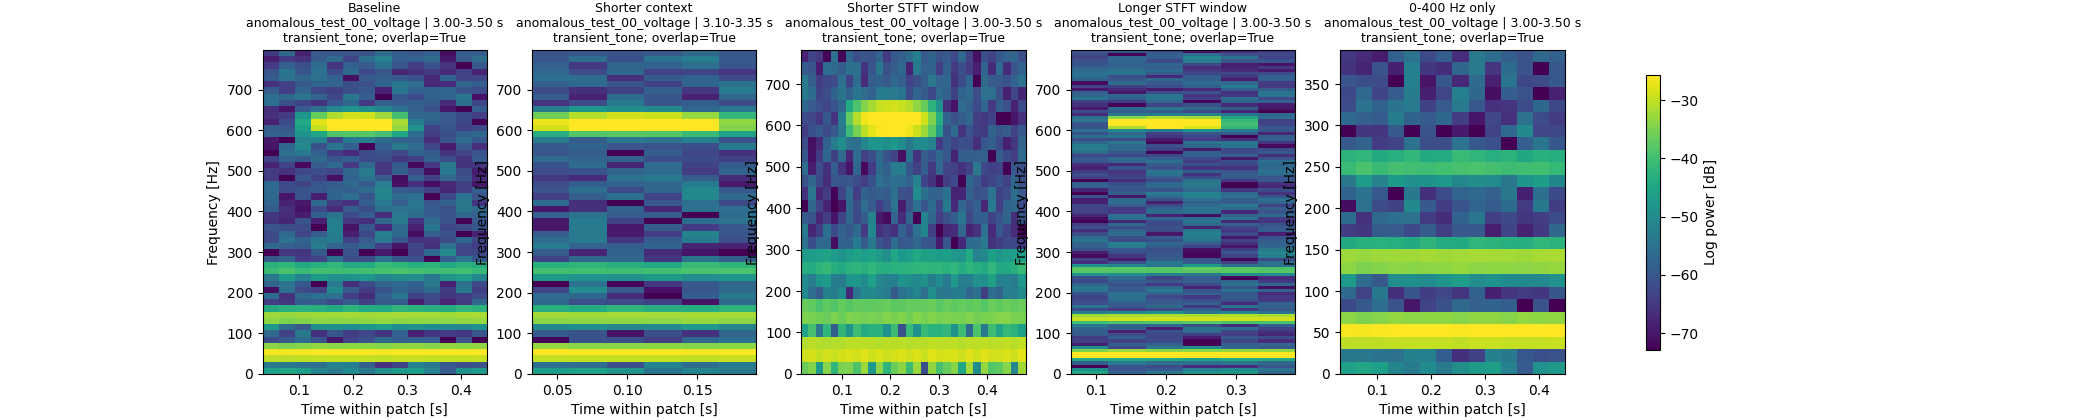

In [12]:
transient_record = next(
    record for record in dataset.test_records
    if record.metadata["external_metadata"].get("anomaly_kind") == "transient_tone"
)
transient_metadata = transient_record.metadata["external_metadata"]
event_center_seconds = 0.5 * (
    transient_metadata["anomaly_start_seconds"] + transient_metadata["anomaly_end_seconds"]
)

variant_configs = {
    "Baseline": config,
    "Shorter context": replace(config, patch_window_seconds=0.25),
    "Shorter STFT window": replace(config, spectrogram_window_seconds=0.032, spectrogram_step_seconds=0.016),
    "Longer STFT window": replace(config, spectrogram_window_seconds=0.128, spectrogram_step_seconds=0.064),
    "0-400 Hz only": replace(config, max_frequency_hz=400.0),
}
variant_patch_sets = {
    name: spectrogram_patches_from_records([transient_record], variant_config)
    for name, variant_config in variant_configs.items()
}


def event_patch_index(patch_set, event_center):
    candidates = patch_set.metadata[patch_set.metadata["known_anomaly_overlap"]]
    if candidates.empty:
        candidates = patch_set.metadata
    return int((candidates["patch_center_seconds"] - event_center).abs().idxmin())


variant_indices = {
    name: event_patch_index(patch_set, event_center_seconds)
    for name, patch_set in variant_patch_sets.items()
}
variant_table = []
for name, variant_config in variant_configs.items():
    patch_set = variant_patch_sets[name]
    row = patch_set.metadata.loc[variant_indices[name]]
    variant_table.append({
        "configuration": name,
        "patch_shape": f"{patch_set.patches.shape[1]} x {patch_set.patches.shape[2]}",
        "frequency_bins": len(patch_set.frequencies_hz),
        "time_bins": len(patch_set.times_seconds),
        "max_frequency_hz": patch_set.frequencies_hz[-1],
        "generated_patches": len(patch_set.patches),
        "selected_interval_seconds": f"{row['patch_start_seconds']:.2f}-{row['patch_end_seconds']:.2f}",
    })
display(pd.DataFrame(variant_table))

variant_values = np.concatenate([
    patch_set.patches[variant_indices[name]].ravel()
    for name, patch_set in variant_patch_sets.items()
])
variant_vmin, variant_vmax = np.percentile(variant_values, [2.0, 98.0])
fig, axes = plt.subplots(1, len(variant_configs), figsize=(21, 4.2))
for ax, name in zip(axes, variant_configs):
    patch_set = variant_patch_sets[name]
    image = plot_log_power_patch(
        ax,
        patch_set,
        variant_indices[name],
        name,
        vmin_db=variant_vmin,
        vmax_db=variant_vmax,
    )
fig.colorbar(image, ax=axes, label="Log power [dB]", shrink=0.85)
fig.suptitle("Same injected transient event under alternative patch configurations", y=1.05)
plt.show()

In [13]:
step_configs = {
    "Dense sampling": replace(config, patch_step_seconds=0.05),
    "Baseline": config,
    "Sparse sampling": replace(config, patch_step_seconds=0.20),
}
step_rows = []
for name, step_config in step_configs.items():
    patch_set = spectrogram_patches_from_records([transient_record], step_config)
    step_rows.append({
        "sampling_choice": name,
        "patch_step_seconds": step_config.patch_step_seconds,
        "patch_overlap_percent": 100.0 * (1.0 - step_config.patch_step_seconds / step_config.patch_window_seconds),
        "generated_patches": len(patch_set.patches),
        "single_patch_shape": f"{patch_set.patches.shape[1]} x {patch_set.patches.shape[2]}",
    })

print("Changing patch_step_seconds changes patch density and overlap, while single-patch image resolution stays fixed.")
display(pd.DataFrame(step_rows))

Changing patch_step_seconds changes patch density and overlap, while single-patch image resolution stays fixed.


,sampling_choice,patch_step_seconds,patch_overlap_percent,generated_patches,single_patch_shape
0,Dense sampling,0.05,90.0,71,52 x 14
1,Baseline,0.10,80.0,36,52 x 14
2,Sparse sampling,0.20,60.0,18,52 x 14


## 5. Train The Spectrogram Autoencoder

Training uses only normal records. If PyTorch is not installed, this cell leaves `result` as `None` and the remaining cells print a short message instead of failing.

In [14]:
if TORCH_AVAILABLE:
    result = run_spectrogram_autoencoder(dataset.train_records, dataset.test_records, config)
    print(result.evaluation.metrics)
else:
    result = None
    print("Skipping training because PyTorch is not installed.")

{'n_train_patches': 288.0, 'n_test_patches': 216.0, 'n_epochs': 20.0, 'threshold': 0.22513620111521865, 'threshold_quantile': 0.95, 'final_training_loss': 0.19625483784410688}


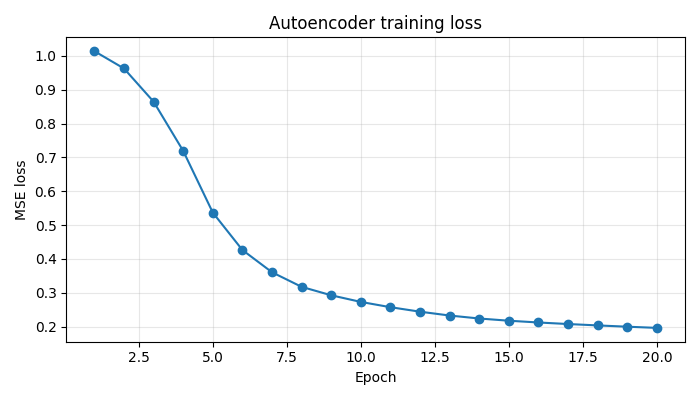

In [15]:
if result is None:
    print("Install the deep-learning extra to train and plot loss.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.arange(1, len(result.training_losses) + 1), result.training_losses, marker="o")
    ax.set_title("Autoencoder training loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.grid(True, alpha=0.3)
    fig.tight_layout();

## 6. Score Test Patches

In [16]:
if result is None:
    predictions = pd.DataFrame()
    print("No predictions because training was skipped.")
else:
    predictions = result.evaluation.predictions.sort_values("anomaly_score", ascending=False)
    display(predictions.head(15))

,row_index,anomaly_score,record_name,label,patch_start_seconds,patch_end_seconds,patch_center_seconds,known_anomaly_overlap,is_synthetic_anomaly_record,anomaly_kind,reconstruction_error,predicted_anomaly,anomaly_rank
53,53,0.292771,anomalous_test_01_voltage,anomalous,1.7,2.2,1.95,True,True,broadband_impulse,0.292771,True,1
54,54,0.284770,anomalous_test_01_voltage,anomalous,1.8,2.3,2.05,True,True,broadband_impulse,0.284770,True,2
52,52,0.256803,anomalous_test_01_voltage,anomalous,1.6,2.1,1.85,True,True,broadband_impulse,0.256803,True,3
113,113,0.256073,normal_test_00_voltage,normal,0.5,1.0,0.75,False,False,NaN,0.256073,True,4
117,117,0.254184,normal_test_00_voltage,normal,0.9,1.4,1.15,False,False,NaN,0.254184,True,5
65,65,0.242976,anomalous_test_01_voltage,anomalous,2.9,3.4,3.15,False,True,broadband_impulse,0.242976,True,6
51,51,0.241408,anomalous_test_01_voltage,anomalous,1.5,2.0,1.75,True,True,broadband_impulse,0.241408,True,7
196,196,0.240704,normal_test_02_voltage,normal,1.6,2.1,1.85,False,False,NaN,0.240704,True,8
188,188,0.240022,normal_test_02_voltage,normal,0.8,1.3,1.05,False,False,NaN,0.240022,True,9
107,107,0.239084,anomalous_test_02_voltage,anomalous,3.5,4.0,3.75,True,True,transient_tone,0.239084,True,10


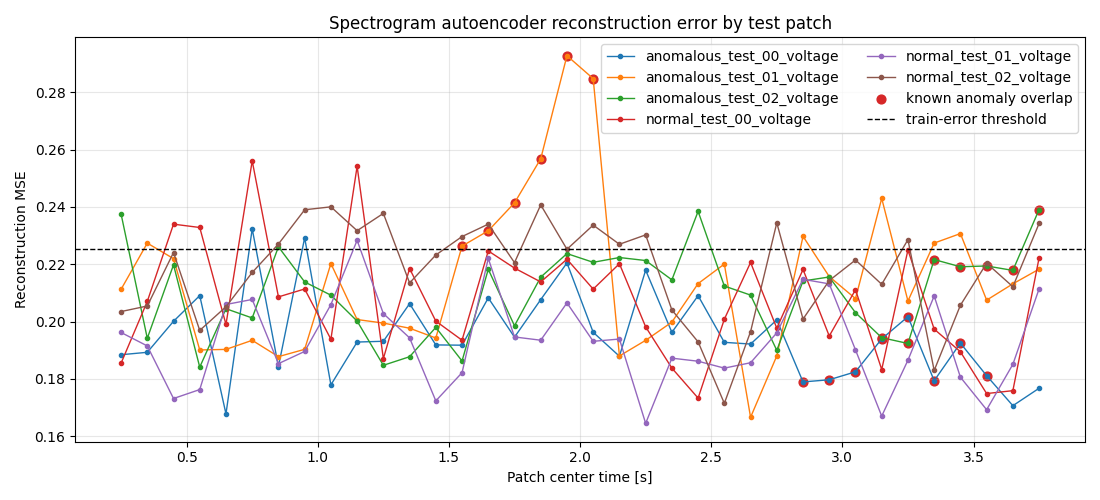

In [17]:
if result is None:
    print("No reconstruction-error timeline because training was skipped.")
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for record_name, group in result.evaluation.predictions.groupby("record_name"):
        ax.plot(group["patch_center_seconds"], group["anomaly_score"], marker=".", linewidth=1.0, label=record_name)
    overlapping = result.evaluation.predictions[result.evaluation.predictions["known_anomaly_overlap"]]
    ax.scatter(overlapping["patch_center_seconds"], overlapping["anomaly_score"], color="tab:red", s=40, label="known anomaly overlap")
    ax.axhline(result.threshold, color="black", linestyle="--", linewidth=1.0, label="train-error threshold")
    ax.set_title("Spectrogram autoencoder reconstruction error by test patch")
    ax.set_xlabel("Patch center time [s]")
    ax.set_ylabel("Reconstruction MSE")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", ncols=2)
    fig.tight_layout();

## 7. Inspect The Highest-Error Patch

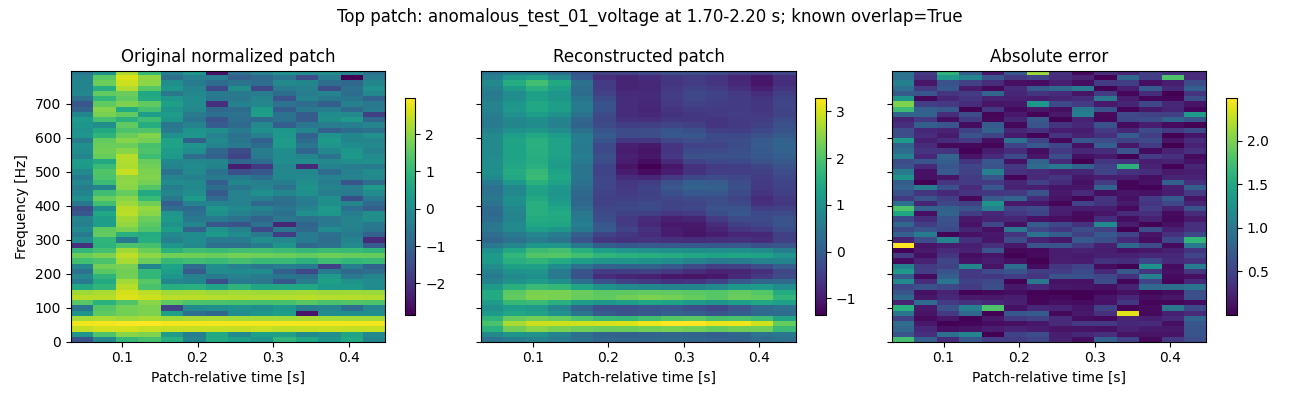

In [18]:
if result is None:
    print("No patch reconstruction to show because training was skipped.")
else:
    top_row = result.evaluation.predictions.sort_values("anomaly_score", ascending=False).iloc[0]
    patch_index = int(top_row["row_index"])
    original = (result.test_patches.patches[patch_index] - result.train_patch_mean) / result.train_patch_std
    reconstructed = result.reconstructed_test_patches[patch_index]
    error = np.abs(original - reconstructed)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
    images = [original, reconstructed, error]
    titles = ["Original normalized patch", "Reconstructed patch", "Absolute error"]
    for ax, image, title in zip(axes, images, titles):
        mesh = ax.imshow(
            image,
            aspect="auto",
            origin="lower",
            extent=[
                result.test_patches.times_seconds[0],
                result.test_patches.times_seconds[-1],
                result.test_patches.frequencies_hz[0],
                result.test_patches.frequencies_hz[-1],
            ],
        )
        ax.set_title(title)
        ax.set_xlabel("Patch-relative time [s]")
        fig.colorbar(mesh, ax=ax, shrink=0.8)
    axes[0].set_ylabel("Frequency [Hz]")
    fig.suptitle(
        f"Top patch: {top_row['record_name']} at {top_row['patch_start_seconds']:.2f}-{top_row['patch_end_seconds']:.2f} s; "
        f"known overlap={top_row['known_anomaly_overlap']}"
    )
    fig.tight_layout();

## 8. Interpretation Limits

This validates the autoencoder workflow on controlled synthetic data. It does not prove that the same neural model is justified for the single unlabeled CSV record.

Important constraints:

- The training set is synthetic normal CSV data by construction.
- Test anomalies are known because they are injected and stored in metadata.
- Reconstruction error is useful here because the train/test setup is explicit.
- The real-data walkthrough remains feature-based because it has no labels and only one short record.